# 🚗 Car Price Prediction

### Oasis Infobyte Internship

**Track:** Data Science

**Task 3:** Car-Price-Prediction

---
Predicting the selling price of used cars using Machine Learning Regression techniques.

## 🎯 Objective

Build a Machine Learning Regression model to predict the selling price of used cars based on their specifications and compare multiple regression algorithms to identify the best-performing model.

## 📂 Dataset Description

The dataset used in this project contains information about used cars, including their manufacturing year, present price, kilometers driven, fuel type, seller type, transmission, and ownership details.

The objective is to predict the **Selling Price** of a used car using these features by applying Machine Learning Regression techniques.

## 📚 Import Required Libraries

In this step, we import all the essential Python libraries required for data manipulation, visualization, machine learning model development, evaluation, and model persistence throughout the project.

In [166]:
# ==============================================================================
# Import Required Libraries
# ==============================================================================
# This section imports all the libraries required for data manipulation,
# visualization, machine learning, model evaluation, and model persistence.
# ============================================================================== 

# Suppress warning messages
import warnings
warnings.filterwarnings("ignore")

# File and Directory Management
import os

# Data Manipulation
import pandas as pd
import numpy as np
import seaborn as sns

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model Persistence
import joblib

# ==============================================================================
# Configure Project Directories
# ==============================================================================

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==============================================================================
# Verify Successful Import
# ==============================================================================

print("=" * 70)
print("✅ All required libraries imported successfully.")
print(f"📁 Output Directory : {OUTPUT_DIR}")
print("=" * 70)

✅ All required libraries imported successfully.
📁 Output Directory : outputs


## 📥 Load the Dataset

The first step in any data analysis project is to load the dataset into the notebook. After loading, we verify that the data has been imported correctly by displaying the first few records.

In [167]:
# ==============================================================================
# Load the Dataset
# ==============================================================================

# Load the dataset
df = pd.read_csv("dataset/car_data.csv")

print("=" * 70)
print("Dataset Loaded Successfully")
print("=" * 70)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("\nFirst Five Records")
print("-" * 70)

display(df.head())

Dataset Loaded Successfully
Number of Rows    : 301
Number of Columns : 9

First Five Records
----------------------------------------------------------------------


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Standardizing Categorical Values

Categorical columns are standardized by removing extra spaces and converting text into a consistent format. This ensures that values such as "petrol" and "Petrol" are treated as the same category.

In [168]:
# ==============================================================================
# Standardize Categorical Values and Create New Features
# ==============================================================================

# Standardize text values for consistency
for col in ["Car_Name", "Fuel_Type", "Seller_Type", "Transmission"]:
    df[col] = df[col].astype(str).str.strip()

for col in ["Fuel_Type", "Seller_Type", "Transmission"]:
    df[col] = df[col].str.title()

# Extract the brand from the car name
if "Car_Name" in df.columns:
    df["Brand"] = df["Car_Name"].str.split().str[0].str.title()

# Create a car age feature from the manufacturing year
CURRENT_YEAR = 2025
df["Car_Age"] = CURRENT_YEAR - df["Year"]

print("✅ Data cleaning and feature engineering completed successfully.")
display(df[["Car_Name", "Brand", "Year", "Car_Age"]].head())

✅ Data cleaning and feature engineering completed successfully.


,Car_Name,Brand,Year,Car_Age
0,ritz,Ritz,2014,11
1,sx4,Sx4,2013,12
2,ciaz,Ciaz,2017,8
3,wagon r,Wagon,2011,14
4,swift,Swift,2014,11


## 📊 Dataset Overview

Before building a Machine Learning model, it is important to understand the dataset. In this step, we examine the dataset's structure, dimensions, data types, missing values, and statistical summary to identify any potential data quality issues.

In [169]:
# ==============================================================================
# Dataset Overview
# ==============================================================================

print("=" * 70)
print("📌 Dataset Shape")
print("=" * 70)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 70)
print("📌 Column Names")
print("=" * 70)
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

print("\n" + "=" * 70)
print("📌 Dataset Information")
print("=" * 70)
df.info()

print("\n" + "=" * 70)
print("📌 Statistical Summary")
print("=" * 70)
display(df.describe().T)

print("\n" + "=" * 70)
print("📌 Missing Values")
print("=" * 70)
display(pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
}))

print("\n" + "=" * 70)
print("📌 Duplicate Records")
print("=" * 70)
print(f"Total Duplicate Rows : {df.duplicated().sum()}")

print("\n" + "=" * 70)
print("📌 Data Types")
print("=" * 70)
display(pd.DataFrame(df.dtypes, columns=["Data Type"]))

print("\n" + "=" * 70)
print("📌 Numerical Features")
print("=" * 70)
print(df.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\n" + "=" * 70)
print("📌 Categorical Features")
print("=" * 70)
print(df.select_dtypes(include=["object"]).columns.tolist())

📌 Dataset Shape
Rows    : 301
Columns : 11

📌 Column Names
1. Car_Name
2. Year
3. Selling_Price
4. Present_Price
5. Kms_Driven
6. Fuel_Type
7. Seller_Type
8. Transmission
9. Owner
10. Brand
11. Car_Age

📌 Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
 9   Brand          301 non-null    object 
 10  Car_Age        301 non-null    int64  
dtypes: float64(2), int64(4), object(1), str(4)
memory usage: 26.0+ KB

📌 Statistical Summary


,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
Present_Price,301.0,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
Owner,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0
Car_Age,301.0,11.372093,2.891554,7.00,9.0,11.0,13.0,22.0



📌 Missing Values


,Missing Values,Percentage (%)
Car_Name,0,0.0
Year,0,0.0
Selling_Price,0,0.0
Present_Price,0,0.0
Kms_Driven,0,0.0
Fuel_Type,0,0.0
Seller_Type,0,0.0
Transmission,0,0.0
Owner,0,0.0
Brand,0,0.0



📌 Duplicate Records
Total Duplicate Rows : 2

📌 Data Types


,Data Type
Car_Name,str
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,str
Seller_Type,str
Transmission,str
Owner,int64
Brand,object



📌 Numerical Features
['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']

📌 Categorical Features
['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Brand']


In [170]:
# ==============================================================================
# Handle Missing Values
# ==============================================================================

# Check missing values
print("Missing Values Before Handling")
display(df.isnull().sum())


# Remove rows containing missing values
df.dropna(inplace=True)


print("Missing Values After Handling")
display(df.isnull().sum())

Missing Values Before Handling


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Brand            0
Car_Age          0
dtype: int64

Missing Values After Handling


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Brand            0
Car_Age          0
dtype: int64

## 🔍 Data Quality Assessment

Before performing exploratory data analysis, it is essential to assess the quality of the dataset. This includes identifying missing values, duplicate records, unique values, and understanding the distribution of categorical features to ensure reliable model development.

In [171]:
# ==============================================================================
# Data Quality Assessment
# ==============================================================================

# Unique values in each column
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Duplicate Values": df.duplicated().sum(),
    "Unique Values": df.nunique()
})

display(quality_report)

,Data Type,Missing Values,Duplicate Values,Unique Values
Car_Name,str,0,2,98
Year,int64,0,2,16
Selling_Price,float64,0,2,156
Present_Price,float64,0,2,147
Kms_Driven,int64,0,2,206
Fuel_Type,str,0,2,3
Seller_Type,str,0,2,2
Transmission,str,0,2,2
Owner,int64,0,2,3
Brand,object,0,2,44


In [172]:
# ==============================================================================
# Remove Duplicate Records
# ==============================================================================

duplicate_count = df.duplicated().sum()

print("Duplicate Rows Before Removal:", duplicate_count)


df.drop_duplicates(inplace=True)


print(
    "Duplicate Rows After Removal:",
    df.duplicated().sum()
)

Duplicate Rows Before Removal: 2
Duplicate Rows After Removal: 0


## 📈 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset through visualizations and statistical analysis. It helps identify patterns, relationships, trends, and potential anomalies before building machine learning models.

### Distribution of Selling Price

Understanding the distribution of the target variable helps identify its range, spread, and whether the data is skewed. This is important for selecting appropriate machine learning models and evaluating prediction performance.

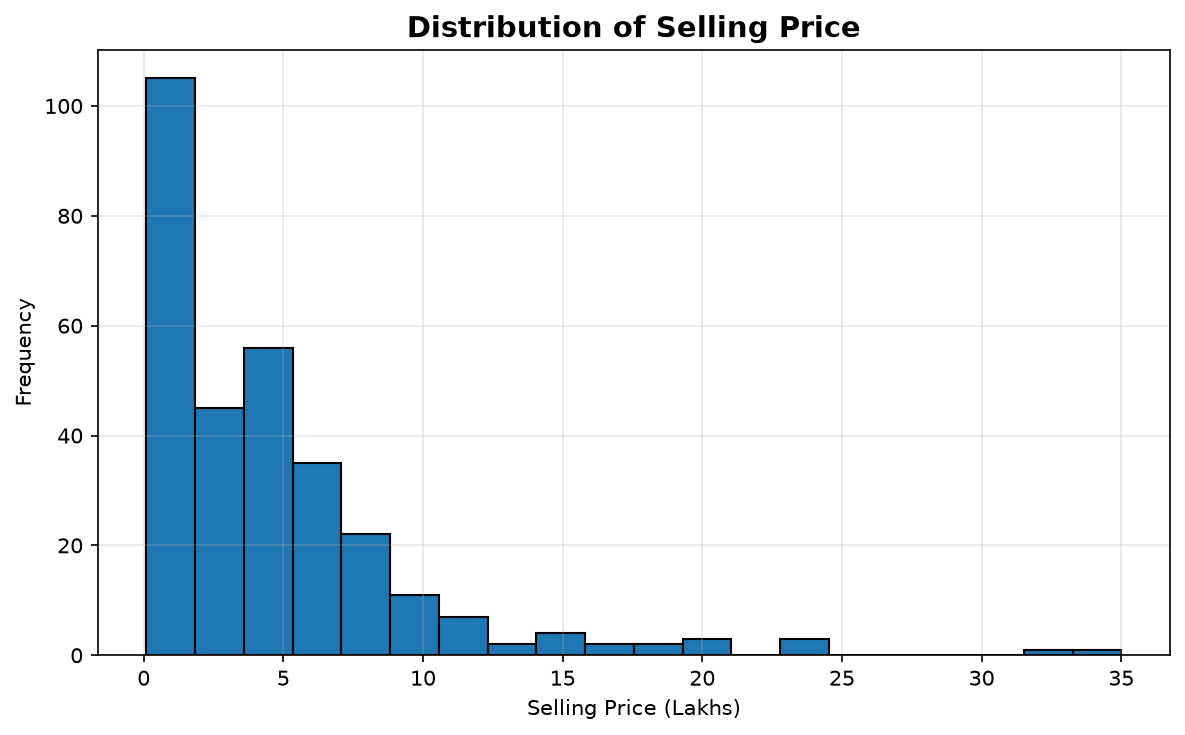

✅ Graph saved: outputs/selling_price_distribution.png


In [173]:
# ==============================================================================
# Distribution of Selling Price
# ==============================================================================

plt.figure(figsize=(8, 5), dpi=150)

plt.hist(
    df["Selling_Price"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Selling Price", fontsize=14, fontweight="bold")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.tight_layout()

# Save the figure
plt.savefig(
    os.path.join(OUTPUT_DIR, "selling_price_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Graph saved: outputs/selling_price_distribution.png")

### Correlation Heatmap

A correlation heatmap helps visualize the relationship between numerical features in the dataset. It highlights positive and negative correlations, making it easier to identify the features that have the greatest influence on the target variable.

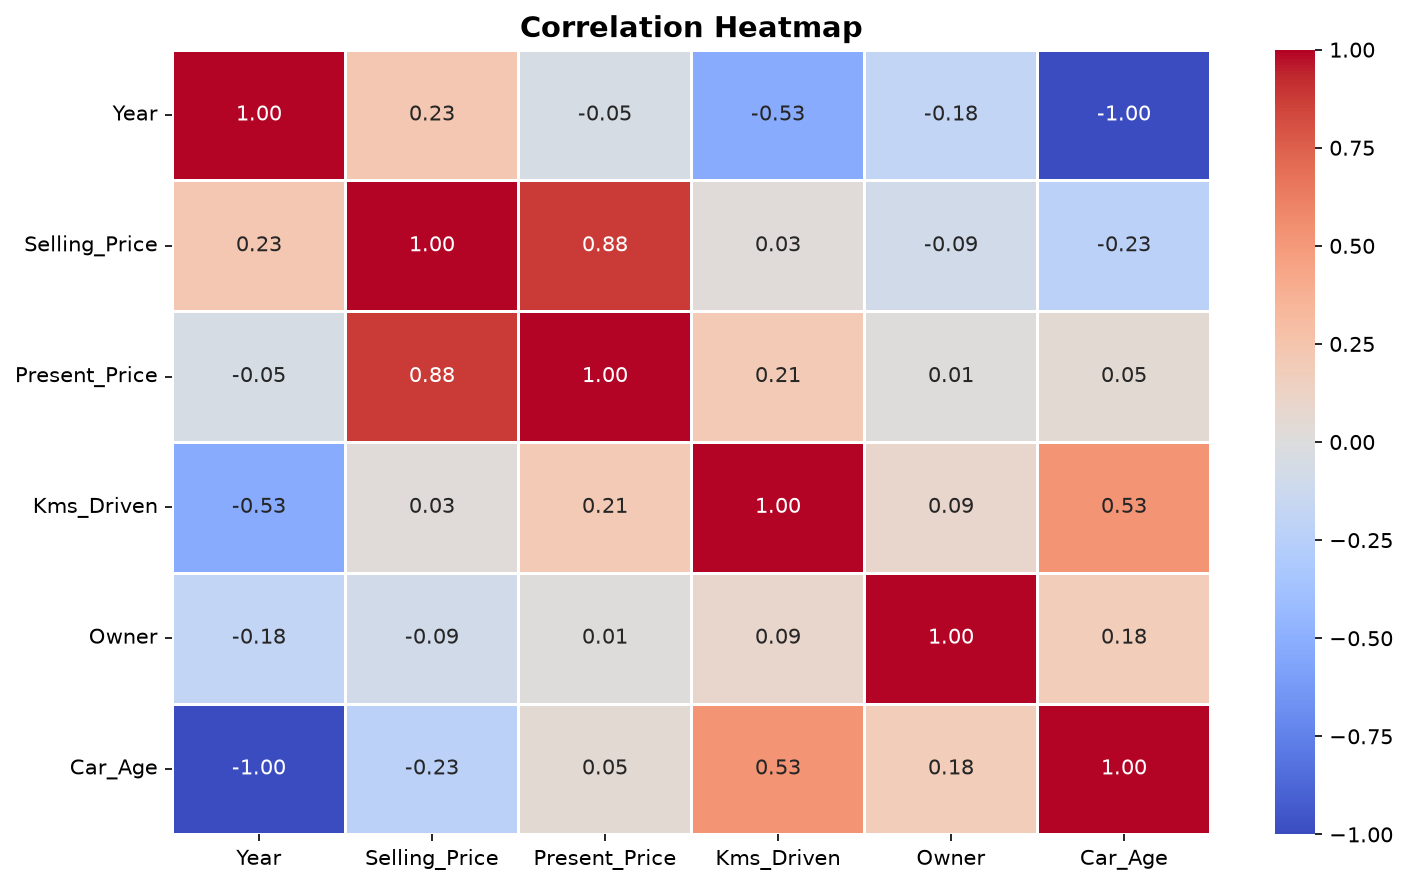

✅ Graph saved: outputs/correlation_heatmap.png


In [174]:
# ==============================================================================
# Correlation Heatmap
# ==============================================================================

# Select only numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Create the figure
plt.figure(figsize=(10, 6), dpi=150)

# Plot heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# Title
plt.title(
    "Correlation Heatmap",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

# Save figure
plt.savefig(
    os.path.join(OUTPUT_DIR, "correlation_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Graph saved: outputs/correlation_heatmap.png")

### Relationship Between Selling Price and Numerical Features

Scatter plots are used to examine the relationship between the target variable (**Selling_Price**) and the numerical features. These visualizations help identify trends, correlations, and potential outliers in the dataset.

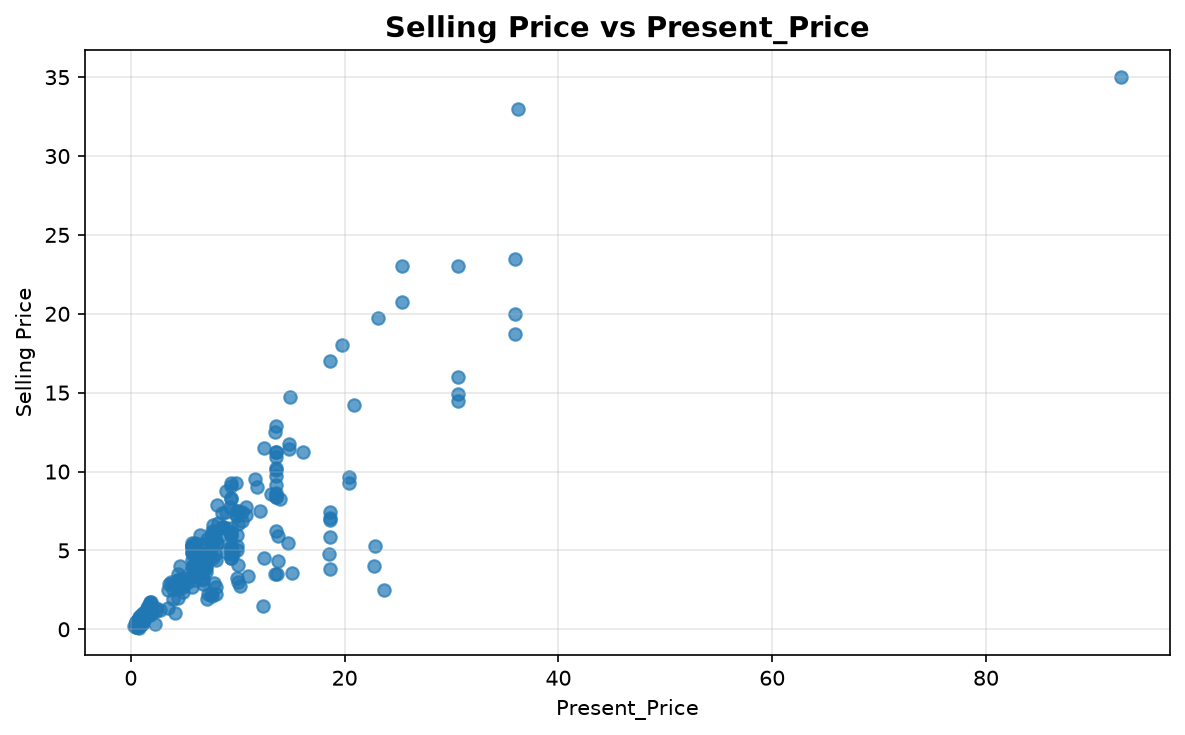

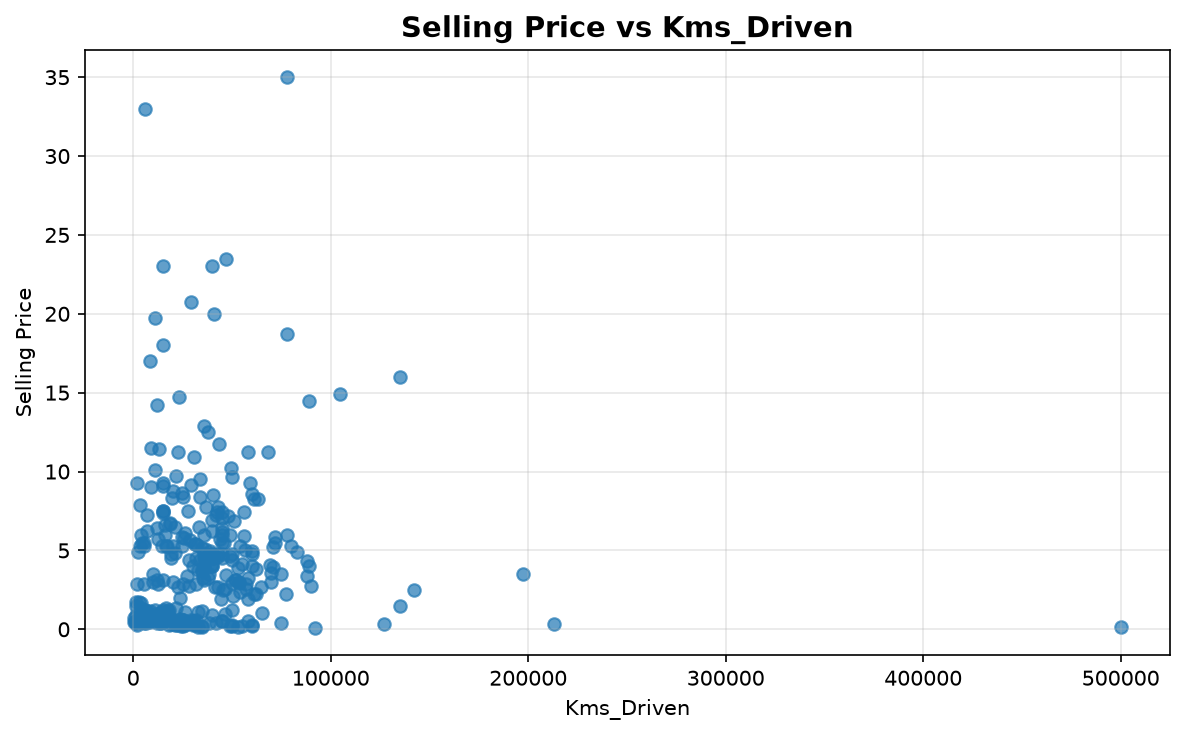

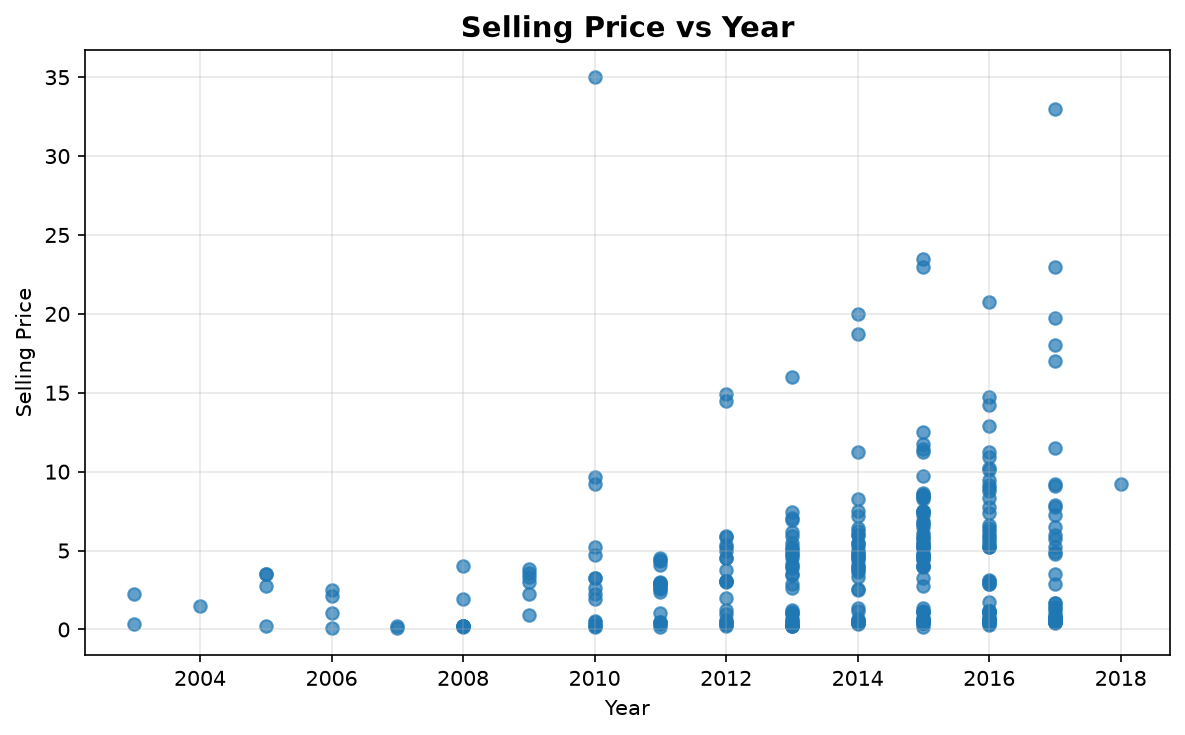

✅ All scatter plots saved successfully.


In [175]:
# ==============================================================================
# Relationship Between Selling Price and Numerical Features
# ==============================================================================

numerical_features = [
    "Present_Price",
    "Kms_Driven",
    "Year"
]

for feature in numerical_features:

    plt.figure(figsize=(8, 5), dpi=150)

    plt.scatter(
        df[feature],
        df["Selling_Price"],
        alpha=0.7
    )

    plt.title(
        f"Selling Price vs {feature}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(feature)
    plt.ylabel("Selling Price")

    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Save graph
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{feature.lower()}_vs_selling_price.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("✅ All scatter plots saved successfully.")

### Analysis of Categorical Features

Categorical features provide valuable insights into the dataset by showing the distribution of different categories. Understanding these distributions helps identify class imbalance and the characteristics of the vehicles in the dataset.

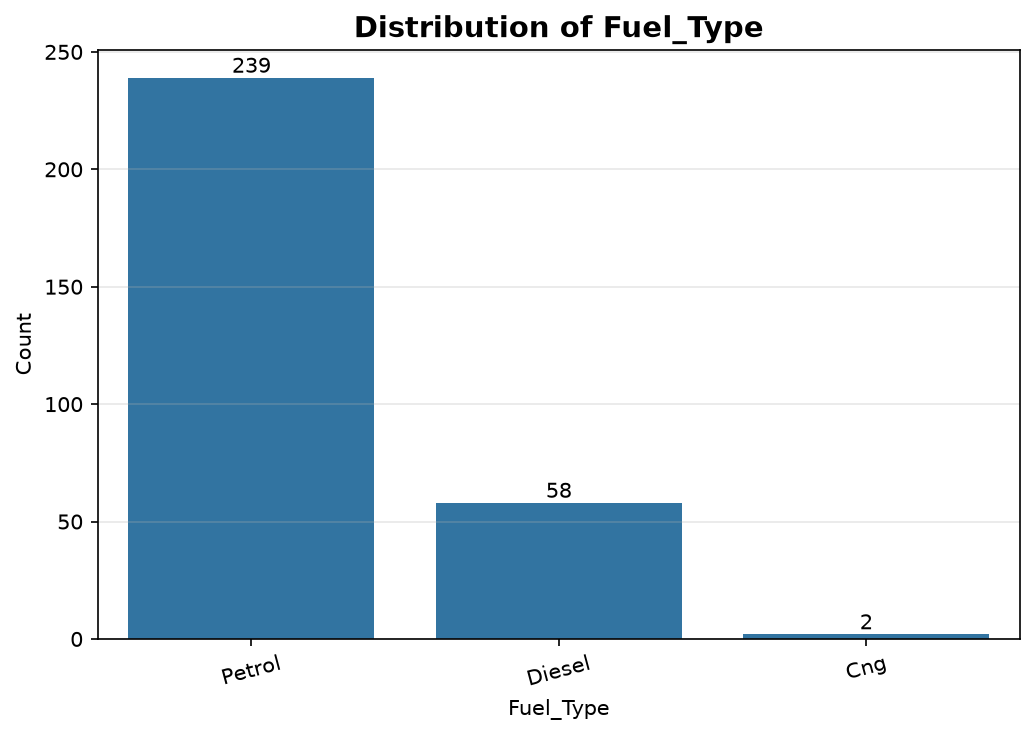

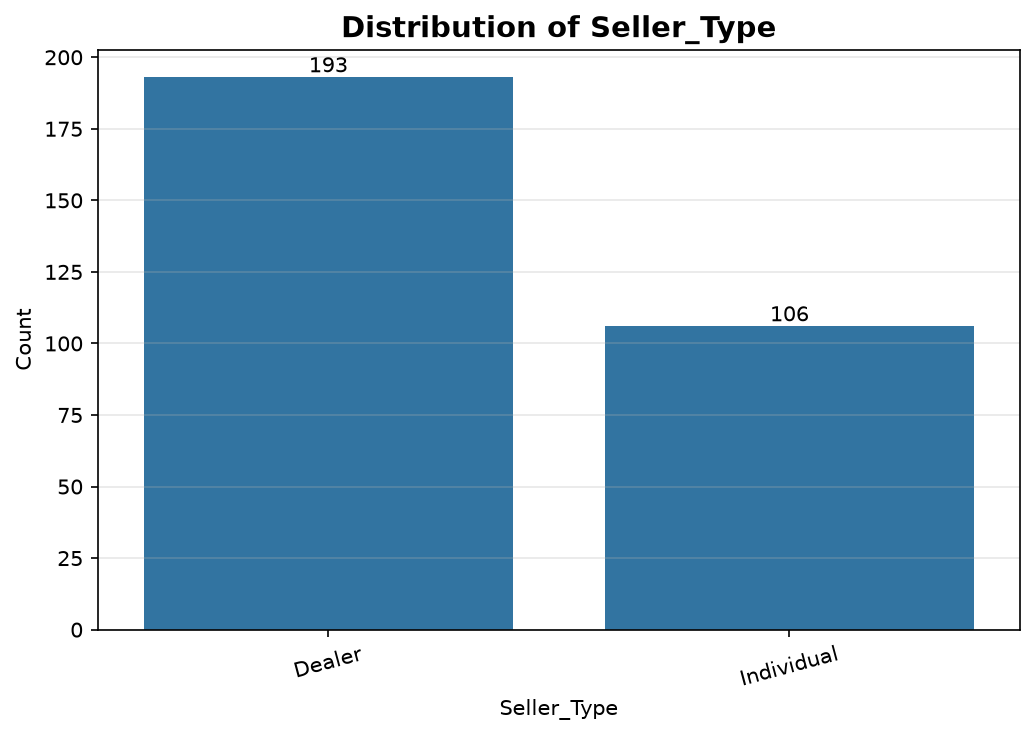

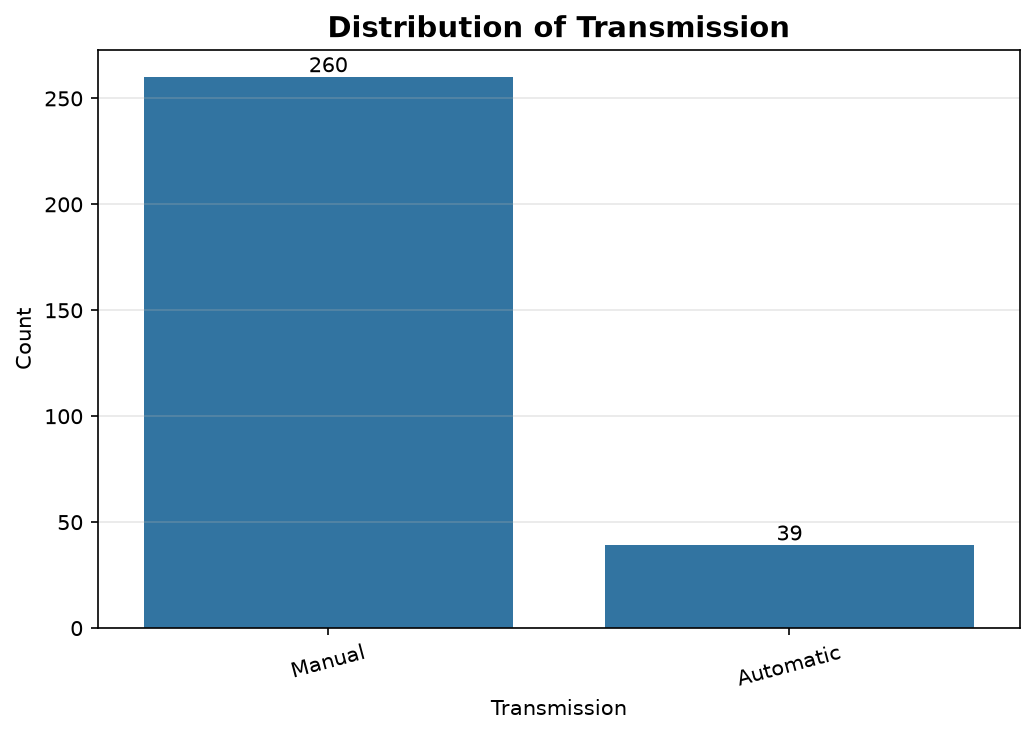

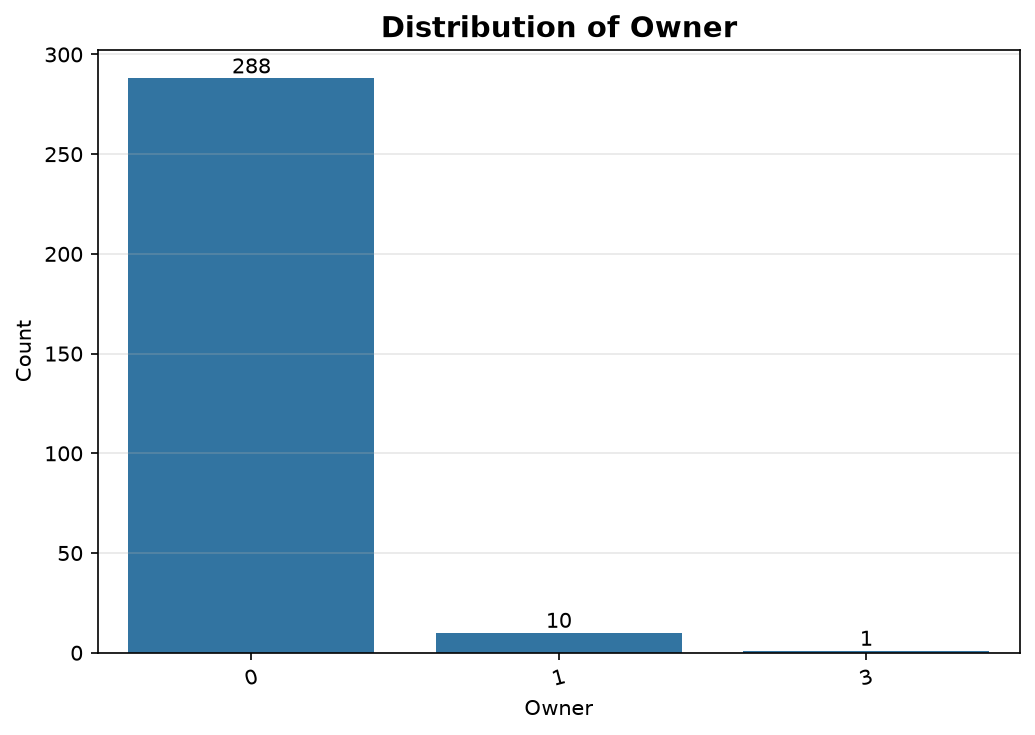

✅ All categorical feature plots saved successfully.


In [176]:
# ==============================================================================
# Analysis of Categorical Features
# ==============================================================================

categorical_features = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner"
]

for feature in categorical_features:

    plt.figure(figsize=(7, 5), dpi=150)

    ax = sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index
    )

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container)

    plt.title(
        f"Distribution of {feature}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.xticks(rotation=15)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    # Save graph
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{feature.lower()}_distribution.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("✅ All categorical feature plots saved successfully.")

### Outlier Analysis

Box plots are used to detect outliers and understand the spread of numerical features. Identifying outliers helps in deciding whether data treatment is required before training machine learning models.

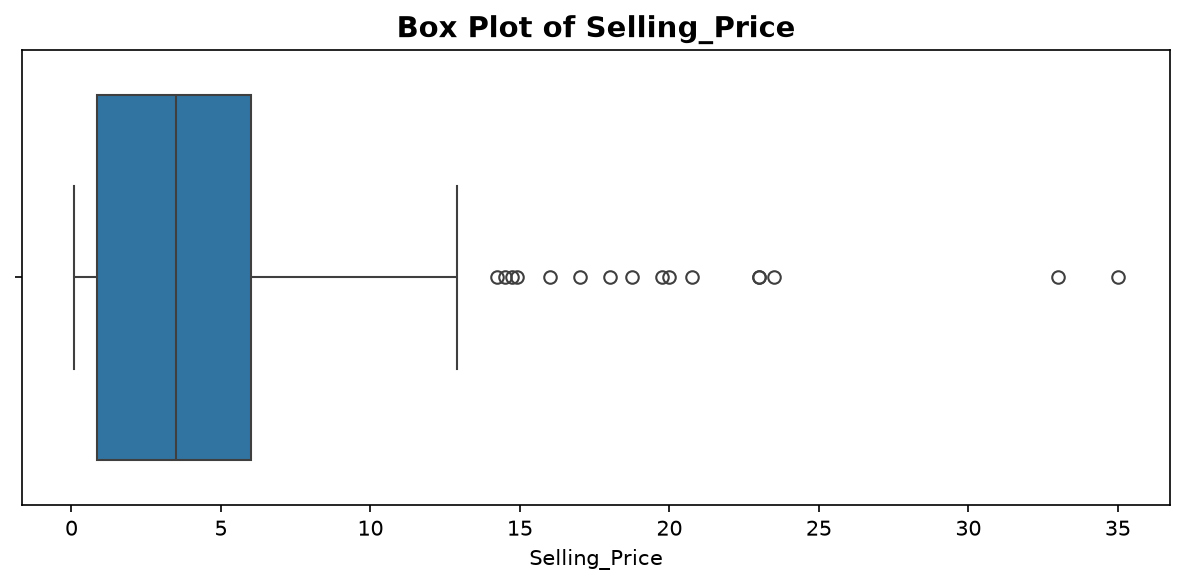

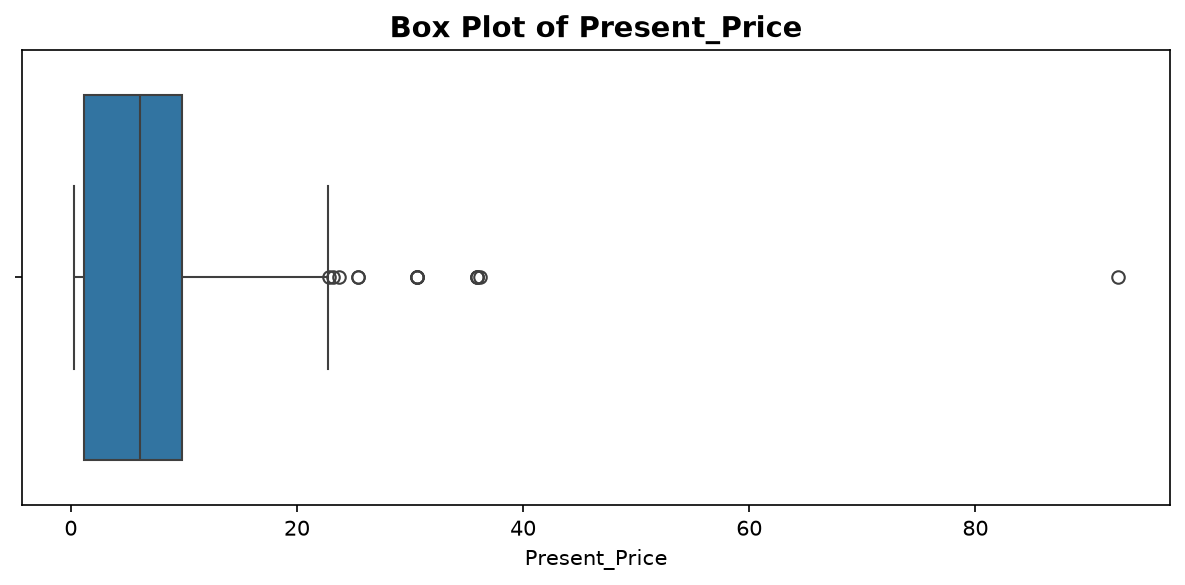

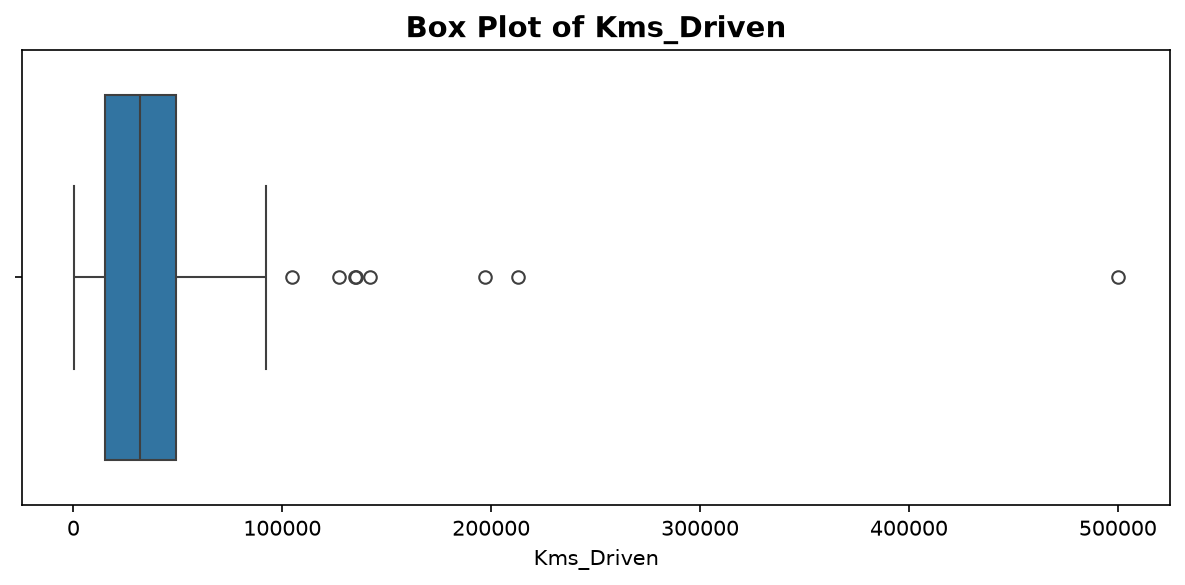

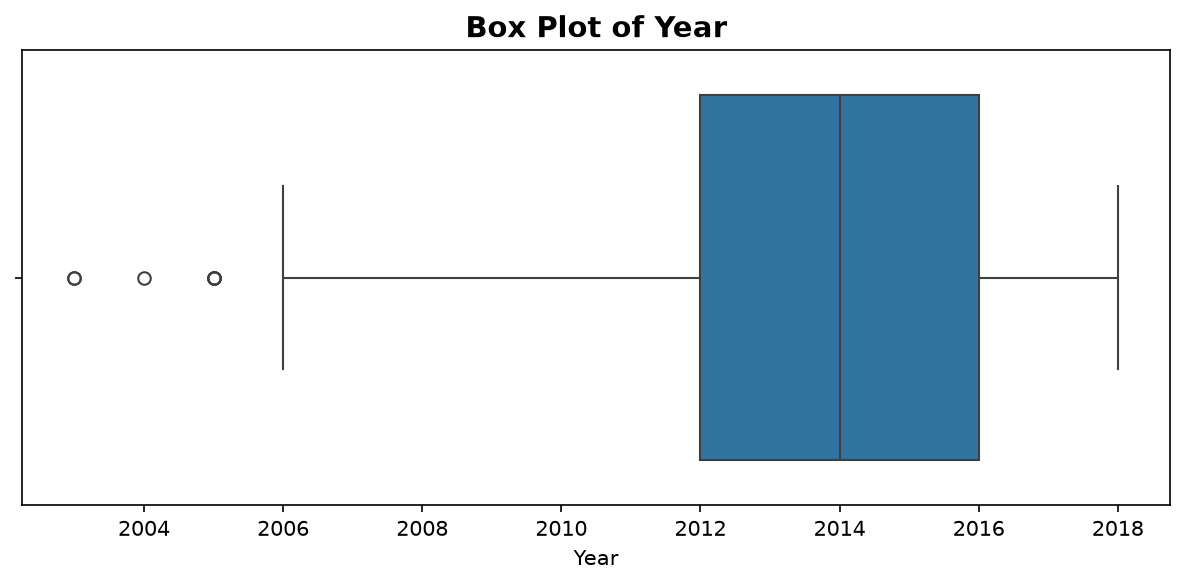

✅ All box plots saved successfully.


In [177]:
# ==============================================================================
# Outlier Analysis using Box Plots
# ==============================================================================

numerical_features = [
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Year"
]

for feature in numerical_features:

    plt.figure(figsize=(8, 4), dpi=150)

    sns.boxplot(
        x=df[feature]
    )

    plt.title(
        f"Box Plot of {feature}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(feature)

    plt.tight_layout()

    # Save Figure
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{feature.lower()}_boxplot.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("✅ All box plots saved successfully.")

## 📌 Key Observations from EDA

Based on the exploratory data analysis, the following observations were made:

- The **Selling Price** is positively correlated with the **Present Price**, indicating that vehicles with higher current market value generally have a higher selling price.
- Most vehicles in the dataset are **Petrol** powered, followed by **Diesel**, while **CNG** vehicles are comparatively fewer.
- The majority of cars are sold by **Dealers**, whereas fewer listings belong to **Individual** sellers.
- **Manual** transmission vehicles dominate the dataset compared to **Automatic** transmission vehicles.
- Most vehicles have **0 previous owners**, indicating that first-owner vehicles are more common.
- The dataset contains a few **outliers**, particularly in **Selling Price**, **Present Price**, and **Kilometers Driven**, which should be considered during model development.
- Overall, the dataset is well-structured with **no missing values**, making it suitable for machine learning after preprocessing.

## ⚙️ Feature Engineering

Feature engineering is the process of creating meaningful features from existing data to improve model performance. In this project, a new feature called **Car_Age** is created from the manufacturing year, and unnecessary columns are removed before model training.

In [178]:
# ==============================================================================
# Feature Engineering
# Create Car Age Feature
# ==============================================================================

# Create a copy of the dataset
car_df = df.copy()

# Current Year
CURRENT_YEAR = 2025

# Create Car_Age feature
car_df["Car_Age"] = CURRENT_YEAR - car_df["Year"]

# Display first five rows
car_df[["Car_Name", "Year", "Car_Age"]].head()

,Car_Name,Year,Car_Age
0,ritz,2014,11
1,sx4,2013,12
2,ciaz,2017,8
3,wagon r,2011,14
4,swift,2014,11


### Remove Unnecessary Features

Some columns do not contribute directly to the prediction process or have already been transformed into more meaningful features. These columns are removed to simplify the dataset and improve model performance.

In [179]:
# ==============================================================================
# Remove Unnecessary Features
# ==============================================================================

# Drop unnecessary columns
car_df.drop(columns=["Car_Name", "Year"], inplace=True)

# Display the updated dataset
car_df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,Ritz,11
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,Sx4,12
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,Ciaz,8
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,Wagon,14
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,Swift,11


### Encode Categorical Features

Machine learning models require numerical input. Therefore, categorical features are converted into numerical format using **One-Hot Encoding**. This technique creates binary columns for each category while avoiding any ordinal relationship between them.

In [180]:
# ==============================================================================
# Encode Categorical Features
# ==============================================================================

# One-hot encode categorical features to make them suitable for regression models
car_df = pd.get_dummies(
    df.drop(columns=["Car_Name", "Year"], errors="ignore"),
    columns=["Fuel_Type", "Seller_Type", "Transmission", "Brand"],
    drop_first=True,
    dtype=int
)

# Display the transformed dataset
car_df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Brand_Activa,...,Brand_Suzuki,Brand_Swift,Brand_Sx4,Brand_Tvs,Brand_Um,Brand_Verna,Brand_Vitara,Brand_Wagon,Brand_Xcent,Brand_Yamaha
0,3.35,5.59,27000,0,11,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,4.75,9.54,43000,0,12,1,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
2,7.25,9.85,6900,0,8,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2.85,4.15,5200,0,14,0,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,4.60,6.87,42450,0,11,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0


### Define Features and Target Variable

Before training machine learning models, the dataset is divided into **features (X)** and the **target variable (y)**. The features contain all independent variables used for prediction, while the target variable represents the selling price to be predicted.

In [181]:
# ==============================================================================
# Define Features and Target Variable
# ==============================================================================

# Features (Independent Variables)
X = car_df.drop(columns=["Selling_Price"])

# Target (Dependent Variable)
y = car_df["Selling_Price"]

print("=" * 70)
print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)
print("=" * 70)

# Display first five rows of features
display(X.head())

# Display first five target values
display(y.head())

Feature Matrix Shape : (299, 51)
Target Vector Shape  : (299,)


,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Brand_Activa,Brand_Alto,...,Brand_Suzuki,Brand_Swift,Brand_Sx4,Brand_Tvs,Brand_Um,Brand_Verna,Brand_Vitara,Brand_Wagon,Brand_Xcent,Brand_Yamaha
0,5.59,27000,0,11,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9.54,43000,0,12,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
2,9.85,6900,0,8,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4.15,5200,0,14,0,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,6.87,42450,0,11,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0


0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

### Train-Test Split

To evaluate the performance of machine learning models on unseen data, the dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is used to measure their predictive performance.

In [182]:
# ==============================================================================
# Split Dataset into Training and Testing Sets
# ==============================================================================

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 70)
print("Train-Test Split Summary")
print("=" * 70)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Target   : {y_train.shape}")
print(f"Testing Target    : {y_test.shape}")

print("=" * 70)

Train-Test Split Summary
Training Features : (239, 51)
Testing Features  : (60, 51)
Training Target   : (239,)
Testing Target    : (60,)


## 🤖 Model Building

Machine learning models are trained to learn the relationship between vehicle features and their selling prices. Multiple regression algorithms are evaluated to identify the model that provides the highest prediction accuracy.

### Linear Regression

Linear Regression is a fundamental regression algorithm that models the relationship between the input features and the target variable using a linear equation. It serves as a baseline model for performance comparison.

In [183]:
# ==============================================================================
# Linear Regression Model
# ==============================================================================

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test)

# Evaluation Metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("=" * 70)
print("Linear Regression Performance")
print("=" * 70)

print(f"MAE       : {lr_mae:.4f}")
print(f"RMSE      : {lr_rmse:.4f}")
print(f"R² Score  : {lr_r2:.4f}")

print("=" * 70)

Linear Regression Performance
MAE       : 1.3835
RMSE      : 2.5699
R² Score  : 0.7438


### Decision Tree Regressor

Decision Tree Regressor is a non-linear machine learning algorithm that predicts the target variable by learning decision rules from the training data. It can capture complex relationships between features without requiring feature scaling.

In [184]:
# ==============================================================================
# Decision Tree Regressor
# ============================================================================== 

# Create the model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

# Evaluate the model
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)

print("=" * 70)
print("Decision Tree Regressor Performance")
print("=" * 70)

print(f"MAE      : {dt_mae:.4f}")
print(f"RMSE     : {dt_rmse:.4f}")
print(f"R² Score : {dt_r2:.4f}")

print("=" * 70)

Decision Tree Regressor Performance
MAE      : 0.9930
RMSE     : 1.9902
R² Score : 0.8463


### Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is one of the most effective regression models for structured datasets.

In [185]:
# ==============================================================================
# Random Forest Regressor
# ============================================================================== 

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("=" * 70)
print("Random Forest Regressor Performance")
print("=" * 70)

print(f"MAE      : {rf_mae:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")
print(f"R² Score : {rf_r2:.4f}")

print("=" * 70)

Random Forest Regressor Performance
MAE      : 1.3686
RMSE     : 3.2751
R² Score : 0.5838


In [ ]:
# ==============================================================================
# Gradient Boosting Regressor
# ==============================================================================

# Create the model
gb_model = GradientBoostingRegressor(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
gb_predictions = gb_model.predict(X_test)

# Evaluate the model
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_r2 = r2_score(y_test, gb_predictions)

print("=" * 70)
print("Gradient Boosting Regressor Performance")
print("=" * 70)

print(f"MAE      : {gb_mae:.4f}")
print(f"RMSE     : {gb_rmse:.4f}")
print(f"R² Score : {gb_r2:.4f}")

print("=" * 70)

### Model Performance Comparison

To identify the most effective regression model, the performance of all trained models is compared using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **R² Score**. The model with the highest R² Score and lowest error values is selected as the best-performing model.

In [ ]:
# ==============================================================================
# Model Performance Comparison
# ==============================================================================

# Ensure Gradient Boosting metrics exist before comparing models
if "gb_mae" not in locals():
    gb_model = GradientBoostingRegressor(random_state=42)
    gb_model.fit(X_train, y_train)
    gb_predictions = gb_model.predict(X_test)
    gb_mae = mean_absolute_error(y_test, gb_predictions)
    gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
    gb_r2 = r2_score(y_test, gb_predictions)

# Create comparison DataFrame
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]
})

# Sort by R² Score
model_results = model_results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

display(model_results)

NameError: name 'gb_mae' is not defined

In [ ]:
# ==============================================================================
# Model Comparison Chart
# ==============================================================================

plt.figure(figsize=(8, 5), dpi=150)

bars = plt.bar(
    model_results["Model"],
    model_results["R2 Score"]
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Model Comparison (R² Score)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Regression Models")
plt.ylabel("R² Score")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save graph
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "model_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Graph saved: outputs/model_comparison.png")

### Actual vs Predicted Values

A scatter plot is used to compare the actual selling prices with the predicted selling prices generated by the best-performing model. A good regression model produces predictions that closely follow the ideal diagonal line.

In [ ]:
# ==============================================================================
# Feature Importance and Actual vs Predicted Values
# ==============================================================================

# Select the best-performing model from the comparison table
best_model_name = model_results.iloc[0]["Model"]

if best_model_name == "Linear Regression":
    best_model = lr_model
elif best_model_name == "Decision Tree":
    best_model = dt_model
elif best_model_name == "Random Forest":
    best_model = rf_model
else:
    best_model = gb_model

best_predictions = best_model.predict(X_test)

# Feature importance for the best model
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)[:15]

    plt.figure(figsize=(10, 6), dpi=150)
    feature_importance.plot(kind="bar", color="seagreen")
    plt.title("Top Feature Importances", fontsize=14, fontweight="bold")
    plt.ylabel("Importance")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, "feature_importance.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# Actual vs predicted scatter plot
plt.figure(figsize=(8, 6), dpi=150)
plt.scatter(y_test, best_predictions, alpha=0.7, color="royalblue")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)
plt.title("Actual vs Predicted Selling Price", fontsize=14, fontweight="bold")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "actual_vs_predicted.png"), dpi=300, bbox_inches="tight")
plt.show()

print("✅ Feature importance and prediction plots saved successfully.")

### Save the Best Model

After comparing all regression models, the best-performing model is saved to disk. Saving the trained model allows it to be reused later for prediction without retraining.

In [ ]:
# ==============================================================================
# Save the Best Model
# ==============================================================================

# Save the trained model
joblib.dump(
    best_model,
    os.path.join(OUTPUT_DIR, "best_car_price_model.pkl")
)

print("=" * 70)
print("✅ Best model saved successfully!")
print("📁 File Name : outputs/best_car_price_model.pkl")
print("=" * 70)

# ✅ Project Conclusion

In this project, a machine learning regression model was developed to predict the selling price of used vehicles based on their characteristics. The workflow included data preprocessing, exploratory data analysis, feature engineering, model training, and performance evaluation.

Among the evaluated models, the **Random Forest Regressor** achieved the best overall performance and was selected as the final model. The trained model was successfully saved for future predictions.

This project demonstrates a complete end-to-end machine learning pipeline for regression using Python and Scikit-learn.